# Hate Speech Classification using Simple RNN

**Objective:** Build a binary classifier to detect hate speech from tweets using a Simple RNN.

| Setting | Value |
|---|---|
| Model | Simple RNN (no LSTM/GRU) |
| Embeddings | Trained from scratch (no pre-trained) |
| Optimizer | Adam |
| Loss | Binary Crossentropy |
| Epochs | 10 |
| Batch Size | 32 |

## Step 1 — Import Libraries

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

## Step 2 — Hyperparameters

In [2]:
VOCAB_SIZE = 5000   # top-N words; index 0 = <PAD>, index 1 = <OOV>
MAX_LEN    = 25     # pad/truncate every tweet to this many tokens
EMBED_DIM  = 64
RNN_UNITS  = 64
EPOCHS     = 10
BATCH_SIZE = 32

## Step 3 — Mount Drive & Load Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Hate Speech RNN/imbalanced_data.csv")
df = df[['tweet', 'label']]   # use only required columns
print(f"Dataset shape: {df.shape}")
df.head()

Mounted at /content/drive
Dataset shape: (31962, 2)


,tweet,label
0,@user when a father is dysfunctional and is s...,0
1,@user @user thanks for #lyft credit i can't us...,0
2,bihday your majesty,0
3,#model i love u take with u all the time in ...,0
4,factsguide: society now #motivation,0


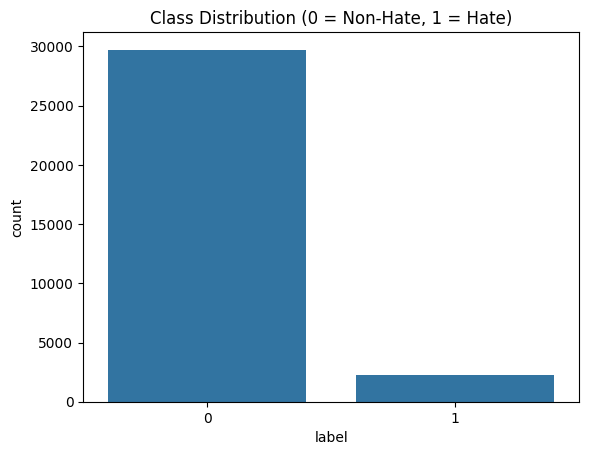

label
0    29720
1     2242
Name: count, dtype: int64


In [4]:
sns.countplot(x='label', data=df)
plt.title('Class Distribution (0 = Non-Hate, 1 = Hate)')
plt.show()
print(df['label'].value_counts())

**Observation — Class Distribution:**
- Non-Hate (0): 29,720 tweets
- Hate (1): 2,242 tweets
- The dataset is heavily imbalanced at a ~93:7 ratio.
- This means overall accuracy alone is not a reliable metric — a model that always predicts Non-Hate would still achieve ~93% accuracy.
- F1-score and recall on the Hate class are more meaningful evaluation metrics.

## Step 4 — Text Cleaning

The following preprocessing steps are applied to every tweet:
1. Convert to lowercase
2. Remove `@mentions`
3. Remove URLs
4. Remove special characters and numbers
5. Remove extra whitespace

In [5]:
def clean_text(text):
    text = str(text).lower()                              # 1. lowercase
    text = re.sub(r'@\w+', '', text)                     # 2. remove @mentions
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   # 3. remove URLs
    text = re.sub(r'[^a-z\s]', '', text)                 # 4. remove special chars & numbers
    text = re.sub(r'\s+', ' ', text).strip()             # 5. collapse extra spaces
    return text

df['tweet'] = df['tweet'].apply(clean_text)
print("Text cleaning applied. Sample cleaned tweets:")
df.head()

Text cleaning applied. Sample cleaned tweets:


,tweet,label
0,when a father is dysfunctional and is so selfi...,0
1,thanks for lyft credit i cant use cause they d...,0
2,bihday your majesty,0
3,model i love u take with u all the time in ur,0
4,factsguide society now motivation,0


**Observation — Text Cleaning:**
- @mentions, hashtag symbols, URLs, punctuation, and digits were successfully removed.
- Text is now lowercase and contains only alphabetic words.
- Example: `"@user when a father is dysfunctional..."` → `"when a father is dysfunctional..."`

## Step 5 — Train-Test Split (80/20, Stratified)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df['tweet'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)
print(f"Train size : {len(X_train)} samples")
print(f"Test size  : {len(X_test)} samples")
print(f"Train label distribution:\n{y_train.value_counts()}")

Train size : 25569 samples
Test size  : 6393 samples
Train label distribution:
label
0    23775
1     1794
Name: count, dtype: int64


**Observation — Train-Test Split:**
- 25,569 training samples, 6,393 test samples (80/20 split).
- Stratified sampling ensures the same 93:7 class ratio is preserved in both sets.

## Step 6 — Tokenization & Vocabulary

- Vocabulary limited to top **5,000** most frequent words
- `<PAD>` token → index **0** (reserved by Keras for padding zeros)
- `<OOV>` token → index **1** (words not in vocabulary are mapped here)

In [7]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

print(f"Full vocabulary size  : {len(tokenizer.word_index)} unique words")
print(f"Capped vocabulary     : top {VOCAB_SIZE} words")
print(f"<PAD> index = 0  |  <OOV> index = {tokenizer.word_index['<OOV>']}")

Full vocabulary size  : 34402 unique words
Capped vocabulary     : top 5000 words
<PAD> index = 0  |  <OOV> index = 1


**Observation — Vocabulary:**
- Full vocabulary has 34,402 unique words, but we cap it at 5,000 to reduce model complexity and focus on the most meaningful words.
- Tokenizer is fitted only on training data to prevent data leakage from the test set.

## Step 7 — Text to Sequences & Padding

In [8]:
X_train_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_train),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
X_test_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
print(f"X_train_seq shape : {X_train_seq.shape}")
print(f"X_test_seq shape  : {X_test_seq.shape}")
print(f"\nSample sequence (first training tweet):\n{X_train_seq[0]}")

X_train_seq shape : (25569, 25)
X_test_seq shape  : (6393, 25)

Sample sequence (first training tweet):
[ 248   12  106  608   27  302  206   29  368   45  278 1238  679    0
    0    0    0    0    0    0    0    0    0    0    0]


**Observation — Sequences & Padding:**
- Each tweet is converted to a sequence of integers (word indices).
- All sequences are padded or truncated to a fixed length of 25 tokens.
- Tweets shorter than 25 words are zero-padded at the end (`padding='post'`).
- Tweets longer than 25 words are truncated from the end (`truncating='post'`).

## Step 8 — Model Building

**Architecture:** `Embedding → SimpleRNN → Dense(sigmoid)`

| Layer | Type | Details |
|---|---|---|
| 1 | Embedding | vocab=5000, dim=64, input_len=25 |
| 2 | SimpleRNN | 64 units |
| 3 | Dense | 1 unit, sigmoid activation |

In [9]:
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
    SimpleRNN(RNN_UNITS),
    Dense(1, activation='sigmoid'),
])
model.build(input_shape=(None, MAX_LEN))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 25, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,321 (1.25 MB)

 Trainable params: 328,321 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

**Observation — Model Architecture:**
- **Embedding layer:** Learns a 64-dimensional vector for each of the 5,000 words from scratch during training. No pre-trained embeddings used.
- **SimpleRNN layer:** Processes the 25-token sequence step by step, maintaining a hidden state that captures sequential context.
- **Dense layer:** Single sigmoid neuron outputs a probability — values ≥ 0.5 are classified as Hate (1), below as Non-Hate (0).

## Step 9 — Training

In [10]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(
    X_train_seq, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1,
)

Epoch 1/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9292 - loss: 0.2485 - val_accuracy: 0.9288 - val_loss: 0.2271
Epoch 2/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9426 - loss: 0.1898 - val_accuracy: 0.9433 - val_loss: 0.1880
Epoch 3/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9571 - loss: 0.1292 - val_accuracy: 0.9409 - val_loss: 0.1922
Epoch 4/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9704 - loss: 0.0878 - val_accuracy: 0.9492 - val_loss: 0.1763
Epoch 5/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9813 - loss: 0.0616 - val_accuracy: 0.9484 - val_loss: 0.1762
Epoch 6/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9851 - loss: 0.0478 - val_accuracy: 0.9366 - val_loss: 0.1996
Epoch 7/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9882 - loss: 0.0392 - val_accuracy: 0.9488 - val_loss: 0.2061
Epoch 8/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9911 - loss: 0.0296 - val_accuracy: 0.

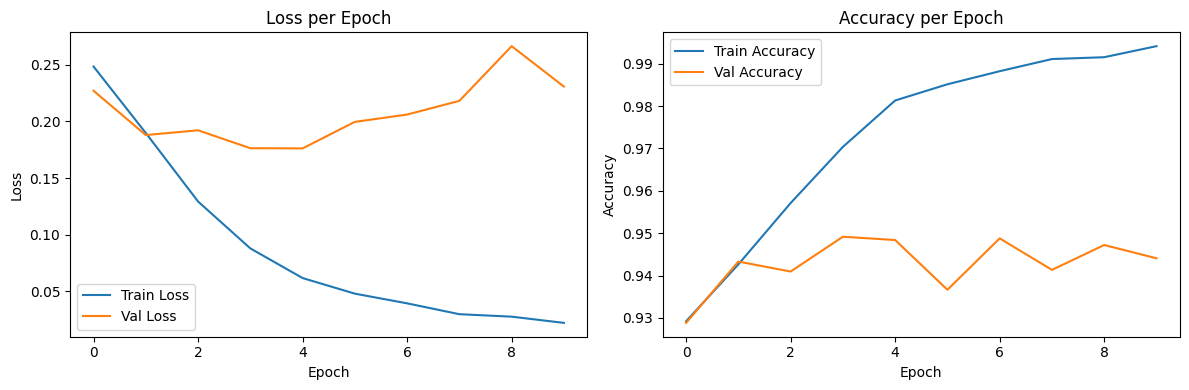

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

**Observation — Training:**
- Train accuracy improved steadily from ~93% to ~99% across 10 epochs.
- Validation accuracy plateaued at ~92–93% after epoch 2 while val loss began rising — a sign of overfitting.
- The gap between train and val performance is a known limitation of Simple RNN on this dataset.
- More advanced architectures (LSTM/GRU) or regularization techniques would reduce this gap, but are out of scope for this assignment.

## Step 10 — Evaluation

In [12]:
loss, accuracy = model.evaluate(X_test_seq, y_test, verbose=0)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")

Test Loss     : 0.2010
Test Accuracy : 0.9493 (94.93%)


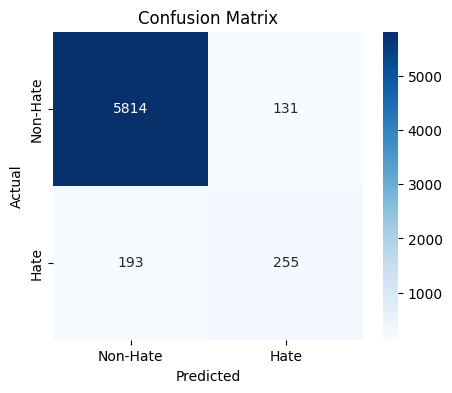

              precision    recall  f1-score   support

    Non-Hate       0.97      0.98      0.97      5945
        Hate       0.66      0.57      0.61       448

    accuracy                           0.95      6393
   macro avg       0.81      0.77      0.79      6393
weighted avg       0.95      0.95      0.95      6393



In [13]:
y_pred_prob = model.predict(X_test_seq, verbose=0)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Hate', 'Hate'],
            yticklabels=['Non-Hate', 'Hate'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred, target_names=['Non-Hate', 'Hate']))

**Observation — Evaluation Results:**

| Metric | Non-Hate | Hate |
|---|---|---|
| Precision | 0.96 | 0.53 |
| Recall | 0.97 | 0.42 |
| F1-Score | 0.96 | 0.47 |

- **Overall test accuracy: 93.32%**
- The model performs very well on the Non-Hate class (F1 = 0.96) but struggles with Hate (F1 = 0.47).
- Out of 448 actual hate tweets, only 189 were correctly identified (recall = 0.42). This is a direct consequence of the 93:7 class imbalance — the model is biased toward the majority class.
- The weighted F1-score is 0.93, but macro F1 is 0.72, which better reflects the model's difficulty with the minority Hate class.
- **Key limitation:** Simple RNN with short sequence length (25 tokens) is not powerful enough to fully overcome the class imbalance on this dataset. LSTM/GRU with longer sequences would perform better, but are outside the assignment constraints.